## Introduction

**NBA Winners Model: Predicting whether a team will win or lose a given NBA Match**

**Goal:** Build a model that can accurately determine if a given team will win an NBA game using only the known information for both teams competing **up to the start of the game**. To this point, I have been able to build a model that attains a **67.2%** test accuracy for predicting the team's outcome, which is right in line with the best performing models that employ classical ML Models (please refer to the Helpful Resources section). 

**Approach:**
Using the `nba_api`, we contruct a dataframe of game by game data for every matchup from the 2012-13 season to this past season, and focus strictly on regular season games. Each instance (row) contains a team of interest (for convenience call them Team 1), Team 1's counting stats and efficiency, Team 1's opponent (call them Team 2), Team 2's counting stats and efficiency, whether Team 1 was at the home or on the road, and finally if Team 1 won the game (our target variable which is 1 for yes and 0 for no).

Becuase we are largely constrainted by results from past NBA games , I use a rolling average of the team's counting statistics (points, rebounds, assists, etc.) over its previous N games as the respective feature itself, and we employ a similar process to get efficiency (shooting percentage) and winning percentage over the last N games for additional features. N is a parameter I toyed around with. In addition, we also incorporate the volatility of these stats as their own features by looking at the standard deviation of each statistic over the last N games. The only feature not reliant on past games is the `At Home` feature, a boolean that is 1 if Team 1 is playing at home and 0 if they are on the road. 

With the dataset ready, I test a variety of classification models: Logistic Regression, Random Forest, XGBoost and Support Vector Classifier, optimizing for **accuracy**. For each model we calculate the accuracy of the vanilla (fully default parameters) model and then employ hyperparameter tuning using GridSearchCV/RandomSearchCV to obtain better performance. **All results are tabulated at the end**

**Application:** Suppose on a given day during the NBA season you wanted to determine the winners and losers of every game being played that night. Using the methods in this notebook you could build a dataset containing the relevant features for each team that is playing, and then you could run our model to determine the outcomes for each team. As such, this is an incredibly useful for fans of the NBA, sports bettors, someone simply wanting to impress their friends, and so on.

**Motivation:**
* Develop highly accurate and functionally useful model with real-world relevance, specifically to the applications outlined above
* Build on skills relevant to Data Science and Analysis (Data Acquisition, Cleaning, Wrangling, Feature Engineering, EDA, Employing Statistical Methods, Modeling, etc.) and on techniques that are helpful to similar projects
* Work on very interesting and open-ended problem where there is a lot of space to explore ideas and unique approaches
* Learn more about feature importance/optimal feature selection as it relates to the NBA (expand domain knowledge)
* Explore passions in NBA analytically

## Imports

In [69]:
# Data wrangling + manipulation
import numpy as np
import pandas as pd
import datetime

# EDA + Data Visualization
from collections import Counter
import matplotlib.pyplot as plt
from great_tables import GT
import plotly.express as px
import seaborn as sns

# NBA API Endpoints and Libraries
from nba_api.stats.endpoints import leaguegamefinder, commonplayerinfo, shotchartdetail, boxscoreadvancedv3, playbyplay, playergamelog, teamgamelog, teamdashlineups, leaguelineupviz
from nba_api.stats.endpoints.shotchartlineupdetail import ConferenceNullable
from nba_api.stats.endpoints.synergyplaytypes import LeagueID
from nba_api.stats.library.parameters import Season, SeasonType, SeasonAll
from nba_api.stats.static import teams, players

# ML modeling
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, recall_score, precision_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV, cross_val_score, ParameterGrid, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import xgboost as xgb

# MLOps
import mlflow

## Create/Load in Main Dataset

This dataset contains data for every NBA game played from the start of the 2012-13 season to the end of the 2023-24 season (including playoffs). Please note that this dataset has additional usage outside the scope of this project, so it will be analyzed and further wrangled later in the "ML Model" section

### Create Dataframe containing relevant game information 

(only run if necessary)

In [70]:
# Helpful Dictionaries for Team/Player Information
nba_teams = teams.get_teams()
team_info = pd.DataFrame.from_dict(nba_teams)
full_name_dict = team_info.set_index('abbreviation').to_dict()['full_name']

# New Orleans Hornets were renamed to New Orleans Pelicans in 2013
full_name_dict['NOH'] = 'New Orleans Pelicans'

# Seasons of interest
start_year = 2012
end_year = datetime.date.today().year - 1

In [71]:
gbg_dfs = []

# Returns the Team ID of Team 2
# [Team 1].[Team 2] or [Team 1]@[Team 2]
# . means Team 1 is at home, @ means Team 1 is on the road, and in either case Team 2 is the second entry
def get_opponent(stri):
  if '@' in stri:
    return stri.replace(' ','').split('@')[1]
  else:
    return stri.replace(' ','').split('.')[1]

# Determine whether the team of interest is playing at home (1) or on the road (0)
def get_location(stri):
  if '@' in stri:
    return 0
  else:
    return 1

# Iterate through each season
for season in [str(x) + '-' + str(x + 1)[2:] for x in range(start_year,end_year+1)]:
    print(season)

    # Get the data for all games in a given season
    games = leaguegamefinder.LeagueGameFinder(
                              league_id_nullable=LeagueID.nba,
                              season_nullable=season)

    # Eastern Conference
    games_dict = games.get_normalized_dict()
    games = games_dict['LeagueGameFinderResults']
    games_df = pd.DataFrame.from_dict(games)

    # Extract Relevant Data & Create Helpful Features
    games_df['GAME_DATE'] = pd.to_datetime(games_df['GAME_DATE'])
    games_df['GAME_TYPE'] = games_df['GAME_ID'].apply(lambda x: x[2])
    games_df['SEASON'] = season
    
    #Filter out preseason, all-star games
    games_df = games_df[(games_df['TEAM_ABBREVIATION'].isin(full_name_dict.keys())) & 
                        ((games_df["GAME_TYPE"] != '1') & 
                         (games_df['GAME_TYPE'] != '3'))]
    
    # Add helpful features for merging and/or information
    games_df['Opponent'] = games_df['MATCHUP'].apply(lambda x: get_opponent(x))
    games_df['At Home'] = games_df['MATCHUP'].apply(lambda x: get_location(x))
    gbg_dfs.append(games_df)

# Combine all the game-by-game dataframes for each season into one table
game_by_game_df = pd.concat(gbg_dfs)

2012-13
2013-14
2014-15
2015-16
2016-17
2017-18
2018-19
2019-20
2020-21
2021-22
2022-23
2023-24
2024-25
2025-26


### Data Wrangling + Feature Engineering

In [72]:
# Create target variable; whether or not the team of interest won
game_by_game_df['Win'] = game_by_game_df['WL'].apply(lambda x: 1 if x == 'W' else 0)

# Columns that either contain relevant features or are crucial for 
# merging dataframes 
key_cols = ['TEAM_ABBREVIATION', 'GAME_ID','GAME_DATE', 'PTS', 'FGM', 'FGA', 'FG_PCT',
       'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB',
       'AST', 'STL', 'BLK', 'TOV', 'PF', 'Win']

# So far we have the statistics for the team of interest, but we also want to 
# store the statistics for the opponent as well; while this may seem like 
# repeating features, this will be helpful for our model
game_by_game_opps_df = game_by_game_df[key_cols]
game_by_game_opps_df = game_by_game_opps_df.add_prefix("Opponent ")
combined_df = game_by_game_df.merge(game_by_game_opps_df,right_on=['Opponent TEAM_ABBREVIATION','Opponent GAME_ID', 'Opponent GAME_DATE'],
                           left_on=['Opponent','GAME_ID','GAME_DATE'])

# Remove uneccessary/non-numeric columns
combined_df = combined_df.drop(['Opponent TEAM_ABBREVIATION', 'Opponent GAME_ID',
       'Opponent GAME_DATE','PLUS_MINUS','TEAM_ID','TEAM_NAME','WL','MIN'],axis=1)

### Save DataFrame for easy reference

In [73]:
combined_df.to_csv('game_by_game.csv', index=False)

## Import DataFrame

Further EDA will be conducted in the ML Model EDA Section

In [74]:
game_by_game_df = pd.read_csv('game_by_game.csv',converters={'GAME_ID': str})

In [75]:
print(game_by_game_df.columns)

# Note that rows with the same GAME_ID are essentially identical;
# this will be resolved in the ML Data Preparation Section
game_by_game_df

Index(['SEASON_ID', 'TEAM_ABBREVIATION', 'GAME_ID', 'GAME_DATE', 'MATCHUP',
       'PTS', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA',
       'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PF',
       'GAME_TYPE', 'SEASON', 'Opponent', 'At Home', 'Win', 'Opponent PTS',
       'Opponent FGM', 'Opponent FGA', 'Opponent FG_PCT', 'Opponent FG3M',
       'Opponent FG3A', 'Opponent FG3_PCT', 'Opponent FTM', 'Opponent FTA',
       'Opponent FT_PCT', 'Opponent OREB', 'Opponent DREB', 'Opponent AST',
       'Opponent STL', 'Opponent BLK', 'Opponent TOV', 'Opponent PF',
       'Opponent Win'],
      dtype='object')


,SEASON_ID,TEAM_ABBREVIATION,GAME_ID,GAME_DATE,MATCHUP,PTS,FGM,FGA,FG_PCT,FG3M,...,Opponent FTA,Opponent FT_PCT,Opponent OREB,Opponent DREB,Opponent AST,Opponent STL,Opponent BLK,Opponent TOV,Opponent PF,Opponent Win
0,42012,SAS,0041200407,2013-06-20,SAS @ MIA,88,31,82,0.378,6,...,16,0.688,11,32,14,8,4,16,19,1
1,42012,MIA,0041200407,2013-06-20,MIA vs. SAS,95,36,82,0.439,12,...,22,0.909,12,31,13,12,3,14,19,0
2,42012,MIA,0041200406,2013-06-18,MIA vs. SAS,103,38,81,0.469,11,...,28,0.750,12,33,13,8,2,13,21,0
3,42012,SAS,0041200406,2013-06-18,SAS @ MIA,100,37,85,0.435,5,...,21,0.762,12,30,23,10,6,15,26,1
4,42012,SAS,0041200405,2013-06-16,SAS vs. MIA,114,42,70,0.600,9,...,23,0.826,12,22,25,8,3,13,24,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34725,22025,SAC,0022500088,2025-10-22,SAC @ PHX,116,47,94,0.500,9,...,28,0.714,18,33,23,7,7,15,25,1
34726,22025,LAL,0022500002,2025-10-21,LAL vs. GSW,109,42,77,0.545,8,...,29,0.897,9,31,29,10,4,18,27,1
34727,22025,GSW,0022500002,2025-10-21,GSW @ LAL,119,38,78,0.487,17,...,28,0.607,7,32,23,7,2,19,21,0
34728,22025,HOU,0022500001,2025-10-21,HOU @ OKC,124,43,97,0.443,11,...,25,0.800,11,27,29,12,4,11,27,1


## ML Model

### Feature Engineering

Given our DataFrame above, we need to modify it such that our model is functionally viable. After all, the goal is to build a model that can predict the winner of a game without knowing what occurs in the game itself. Instead I opted to change each team statistic (Points, Assists, Steals, etc.) to the average of that statistic over the last N games, where N is a parameter we play around with.

In this section we update our features to only contain info that is available to us before the game starts, averaging counting stats, win percentage, efficiency stats, etc. over the last N games

In [76]:
# Last N Games
window_size = 5

# But for wins, we keep this at win percentage over last 10 games for now
win_window_size = 10
test_df = game_by_game_df.sort_values(by=['TEAM_ABBREVIATION','GAME_DATE']).reset_index(drop=True)

# Calculate win percentage up to upcoming game
test_df['Cum Wins'] = test_df.groupby(['TEAM_ABBREVIATION','SEASON']).apply(lambda x:
    x.Win.cumsum().shift(1)).reset_index(drop=True)
test_df = test_df.fillna(0)
test_df['Games so Far'] = test_df.groupby(['TEAM_ABBREVIATION','SEASON']).cumcount()
test_df['Win Percentage'] = test_df['Cum Wins'] / test_df['Games so Far']

# Calculate rolling win percentage over last 10 games
test_df[f'L{win_window_size} Win Percentage'] = test_df[['TEAM_ABBREVIATION','SEASON','Win']]\
    .groupby(['TEAM_ABBREVIATION','SEASON'])['Win'].shift(1).rolling(window=win_window_size).sum().reset_index(drop=True) / win_window_size

# For All other Aggregated Features
averaged_features = ['BLK','AST','STL','TOV','PF','OREB','DREB','PTS']
for feature in averaged_features:
    test_df[f'L{str(window_size)} {feature}S Avg'] = test_df.groupby(['TEAM_ABBREVIATION','SEASON'])[feature].shift(1).rolling(window=window_size).mean().reset_index(drop=True) 
    test_df[f'L{str(window_size)} {feature}S Avg Against'] = test_df.groupby(['TEAM_ABBREVIATION','SEASON'])[f'Opponent {feature}'].shift(1).rolling(window=window_size).mean().reset_index(drop=True) 
    test_df[f'L{str(window_size)} {feature}S Variability'] = test_df.groupby(['TEAM_ABBREVIATION','SEASON'])[feature].shift(1).rolling(window=window_size).std().reset_index(drop=True) 
    test_df[f'L{str(window_size)} {feature}S Variability Against'] = test_df.groupby(['TEAM_ABBREVIATION','SEASON'])[f'Opponent {feature}'].shift(1).rolling(window=window_size).std().reset_index(drop=True) 
    if feature not in ['FTA','FGA','PTS']:
        test_df = test_df.drop([feature, f'Opponent {feature}'],axis=1)

# True Shooting Percentages Features 

# Step 1: Get total sum of attempts and makes
pct_features = ['FTA','FGA','PTS']

for feature in pct_features:
    test_df[f'L{str(window_size)} {feature}'] = test_df.groupby(['TEAM_ABBREVIATION','SEASON'])[feature].shift(1).rolling(window=window_size).sum().reset_index(drop=True) 
    test_df[f'Allowed L{str(window_size)} {feature}'] = test_df.groupby(['TEAM_ABBREVIATION','SEASON'])[f'Opponent {feature}'].shift(1).rolling(window=window_size).sum().reset_index(drop=True) 
    test_df = test_df.drop([feature, f'Opponent {feature}'],axis=1)


# Step 2: Calculate Percentages
test_df[f'L{window_size} True Shooting Pct'] = 100 * test_df[f'L{str(window_size)} PTS'] / (2 * test_df[f'L{str(window_size)} FGA'] + 0.44 * test_df[f'L{str(window_size)} FTA'])
test_df[f'L{window_size} True Shooting Pct Allowed'] = 100 * test_df[f'Allowed L{str(window_size)} PTS'] / (2 * test_df[f'Allowed L{str(window_size)} FGA'] + 0.44 * test_df[f'Allowed L{str(window_size)} FTA'])

# Drop unnecessary columns
drop_cols = ['SEASON_ID','GAME_DATE','MATCHUP','FG_PCT','FG3_PCT','FT_PCT','REB',
'GAME_TYPE','SEASON', 'Opponent FG_PCT','Opponent FG3_PCT','Opponent FT_PCT', 'Cum Wins', 'Games so Far',
'Opponent Win','FGM','FG3M','FTM','Opponent FGM','Opponent FG3M','Opponent FTM',
f'L{window_size} FTA', f'Allowed L{window_size} FTA', f'L{window_size} FGA', f'Allowed L{window_size} FGA', 
f'L{window_size} PTS', f'Allowed L{window_size} PTS', 'FG3A','Opponent FG3A']

# Show data
test_df = test_df.drop(drop_cols, axis = 1)
test_df.head(20).tail(10)

/var/folders/g9/448dp20j3mx11dbcj_3c0yx40000gn/T/ipykernel_48032/4110615838.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_df['Cum Wins'] = test_df.groupby(['TEAM_ABBREVIATION','SEASON']).apply(lambda x:


,TEAM_ABBREVIATION,GAME_ID,Opponent,At Home,Win,Win Percentage,L10 Win Percentage,L5 BLKS Avg,L5 BLKS Avg Against,L5 BLKS Variability,...,L5 DREBS Avg,L5 DREBS Avg Against,L5 DREBS Variability,L5 DREBS Variability Against,L5 PTSS Avg,L5 PTSS Avg Against,L5 PTSS Variability,L5 PTSS Variability Against,L5 True Shooting Pct,L5 True Shooting Pct Allowed
10,ATL,0021200171,CHA,0,1,0.600000,0.6,4.4,3.6,0.547723,...,31.0,35.0,5.431390,6.670832,95.4,89.4,11.928956,10.853571,54.674247,51.657190
11,ATL,0021200185,LAC,1,1,0.636364,0.7,6.6,4.2,4.722288,...,30.8,34.6,5.263079,7.021396,96.6,90.2,12.177849,10.779610,55.714483,52.119447
12,ATL,0021200212,CHA,1,1,0.666667,0.7,6.2,4.6,5.069517,...,32.2,33.8,3.701351,7.328028,99.8,90.4,11.432410,10.830512,57.725233,51.756515
13,ATL,0021200227,CLE,1,0,0.692308,0.7,7.0,6.0,5.147815,...,31.6,35.6,3.974921,6.268971,96.2,89.4,9.257429,10.406729,54.217954,52.020296
14,ATL,0021200260,DEN,1,1,0.642857,0.7,7.2,5.6,5.019960,...,27.8,33.0,6.058052,4.301163,102.2,97.6,6.140033,9.370165,58.498947,56.169429
15,ATL,0021200273,WAS,1,1,0.666667,0.8,7.2,5.2,5.019960,...,28.0,31.0,6.041523,2.915476,103.6,98.4,6.580274,9.787747,58.954748,57.934153
16,ATL,0021200289,MEM,0,1,0.687500,0.8,4.4,4.2,3.130495,...,27.6,30.2,5.594640,3.962323,104.2,99.2,6.418723,9.176056,58.222699,59.146196
17,ATL,0021200300,MIA,0,0,0.705882,0.9,4.6,4.6,2.966479,...,27.4,30.0,5.458938,4.000000,102.0,97.2,8.154753,11.627553,56.767587,57.890223
18,ATL,0021200310,ORL,0,1,0.666667,0.8,3.0,3.8,2.000000,...,26.4,28.8,5.549775,2.280351,101.6,99.2,8.677557,11.144505,58.350563,60.408243
19,ATL,0021200322,CHA,1,1,0.684211,0.8,3.2,3.8,2.280351,...,29.8,28.4,4.147288,1.949359,96.6,92.6,9.099451,10.691118,55.673383,57.284965


In [77]:
# Examine features for a given team
test_df.columns

Index(['TEAM_ABBREVIATION', 'GAME_ID', 'Opponent', 'At Home', 'Win',
       'Win Percentage', 'L10 Win Percentage', 'L5 BLKS Avg',
       'L5 BLKS Avg Against', 'L5 BLKS Variability',
       'L5 BLKS Variability Against', 'L5 ASTS Avg', 'L5 ASTS Avg Against',
       'L5 ASTS Variability', 'L5 ASTS Variability Against', 'L5 STLS Avg',
       'L5 STLS Avg Against', 'L5 STLS Variability',
       'L5 STLS Variability Against', 'L5 TOVS Avg', 'L5 TOVS Avg Against',
       'L5 TOVS Variability', 'L5 TOVS Variability Against', 'L5 PFS Avg',
       'L5 PFS Avg Against', 'L5 PFS Variability',
       'L5 PFS Variability Against', 'L5 OREBS Avg', 'L5 OREBS Avg Against',
       'L5 OREBS Variability', 'L5 OREBS Variability Against', 'L5 DREBS Avg',
       'L5 DREBS Avg Against', 'L5 DREBS Variability',
       'L5 DREBS Variability Against', 'L5 PTSS Avg', 'L5 PTSS Avg Against',
       'L5 PTSS Variability', 'L5 PTSS Variability Against',
       'L5 True Shooting Pct', 'L5 True Shooting Pct Allowed

### Add Opponent Features to Every Entry

So far we have the key features for Team 1 in every row, but we want to include the same features for the opponent; we do this by creating a copy of the DataFrame and merging it with the dataset where Team 2's TEAMID and GAMEID of one table equals Team 1's TEAMID and GAMEID of the other

In [78]:
test_df_opp = test_df
test_df_opp = test_df_opp.add_prefix("Opponent ")
full_df = test_df.merge(test_df_opp,right_on=['Opponent TEAM_ABBREVIATION','Opponent GAME_ID'],
                           left_on=['Opponent','GAME_ID'])
full_df = full_df.drop(['Opponent GAME_ID', 'Opponent Opponent', 'Opponent TEAM_ABBREVIATION',
'Opponent At Home', 'Opponent Win'],axis=1)
full_df = full_df.dropna().reset_index(drop=True)
info_df = full_df[['TEAM_ABBREVIATION','GAME_ID','Opponent']]

# Here we drop rows with a repeated GAME_ID to avoid double counting entries
full_df = full_df.loc[list(full_df['GAME_ID'].drop_duplicates().index)]
full_df = full_df.drop(['TEAM_ABBREVIATION','GAME_ID','Opponent'],axis=1)
full_df.columns

Index(['At Home', 'Win', 'Win Percentage', 'L10 Win Percentage', 'L5 BLKS Avg',
       'L5 BLKS Avg Against', 'L5 BLKS Variability',
       'L5 BLKS Variability Against', 'L5 ASTS Avg', 'L5 ASTS Avg Against',
       'L5 ASTS Variability', 'L5 ASTS Variability Against', 'L5 STLS Avg',
       'L5 STLS Avg Against', 'L5 STLS Variability',
       'L5 STLS Variability Against', 'L5 TOVS Avg', 'L5 TOVS Avg Against',
       'L5 TOVS Variability', 'L5 TOVS Variability Against', 'L5 PFS Avg',
       'L5 PFS Avg Against', 'L5 PFS Variability',
       'L5 PFS Variability Against', 'L5 OREBS Avg', 'L5 OREBS Avg Against',
       'L5 OREBS Variability', 'L5 OREBS Variability Against', 'L5 DREBS Avg',
       'L5 DREBS Avg Against', 'L5 DREBS Variability',
       'L5 DREBS Variability Against', 'L5 PTSS Avg', 'L5 PTSS Avg Against',
       'L5 PTSS Variability', 'L5 PTSS Variability Against',
       'L5 True Shooting Pct', 'L5 True Shooting Pct Allowed',
       'Opponent Win Percentage', 'Opponent L10 

### Prepare Data For Modeling

With the dataset now complete, we split our table into our feature dataset (X) and our target variable dataset (Y). We opt to use an 80/20 train/test split.

In [79]:
X = full_df[[x for x in full_df.columns if x != 'Win']]
Y = full_df['Win']

# For consistency across models
random_seed = 42

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=random_seed)

# Optional: When running entire coding section, you might not want to 
# run hyperparameter tuning as it is time consuming
DO_SEARCH = False

### EDA

Conduct exploratory data analysis (EDA) for our datasets, in particular our feature dataset X

#### Check Target Variable Matrix

Ensure that there is a rougly equal sample of wins (1) and losses (0)

In [80]:
Counter(Y)

Counter({1: 7766, 0: 7415})

In [81]:
X.describe(include='all')

,At Home,Win Percentage,L10 Win Percentage,L5 BLKS Avg,L5 BLKS Avg Against,L5 BLKS Variability,L5 BLKS Variability Against,L5 ASTS Avg,L5 ASTS Avg Against,L5 ASTS Variability,...,Opponent L5 DREBS Avg,Opponent L5 DREBS Avg Against,Opponent L5 DREBS Variability,Opponent L5 DREBS Variability Against,Opponent L5 PTSS Avg,Opponent L5 PTSS Avg Against,Opponent L5 PTSS Variability,Opponent L5 PTSS Variability Against,Opponent L5 True Shooting Pct,Opponent L5 True Shooting Pct Allowed
count,15181.000000,15181.000000,15181.000000,15181.000000,15181.000000,15181.000000,15181.000000,15181.000000,15181.000000,15181.000000,...,15181.000000,15181.000000,15181.000000,15181.000000,15181.000000,15181.000000,15181.000000,15181.000000,15181.000000,15181.000000
mean,0.500823,0.516376,0.515151,4.809670,4.837310,2.220494,2.228354,24.151663,24.020065,4.375525,...,33.168816,33.067874,4.766823,4.782418,107.993479,107.856584,10.623560,10.806811,59.048071,59.030983
std,0.500016,0.159898,0.205689,1.328405,1.287579,0.881277,0.891085,3.337415,3.052626,1.629256,...,2.986238,2.960929,1.734246,1.757071,8.773691,8.885215,3.930522,3.987507,3.808743,3.741454
min,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,12.800000,13.000000,0.000000,...,21.800000,22.400000,0.000000,0.000000,78.400000,77.800000,1.140175,0.836660,46.409925,45.238197
25%,0.000000,0.411765,0.400000,3.800000,4.000000,1.581139,1.581139,21.800000,22.000000,3.209361,...,31.200000,31.000000,3.535534,3.507136,101.800000,101.600000,7.765307,7.886698,56.437582,56.453449
50%,1.000000,0.526316,0.500000,4.800000,4.800000,2.167948,2.167948,24.000000,24.000000,4.242641,...,33.000000,33.000000,4.636809,4.658326,108.200000,107.800000,10.295630,10.559356,59.039652,59.046726
75%,1.000000,0.627660,0.700000,5.600000,5.600000,2.738613,2.774887,26.400000,26.000000,5.403702,...,35.000000,35.000000,5.856620,5.890671,114.200000,114.000000,13.160547,13.405223,61.651287,61.589806
max,1.000000,1.000000,1.000000,11.400000,11.800000,7.259477,7.529940,36.600000,36.200000,11.335784,...,47.800000,47.600000,13.397761,12.696456,137.000000,140.200000,29.342802,28.986204,72.987659,72.291035


#### Correlation Heatmap for Features

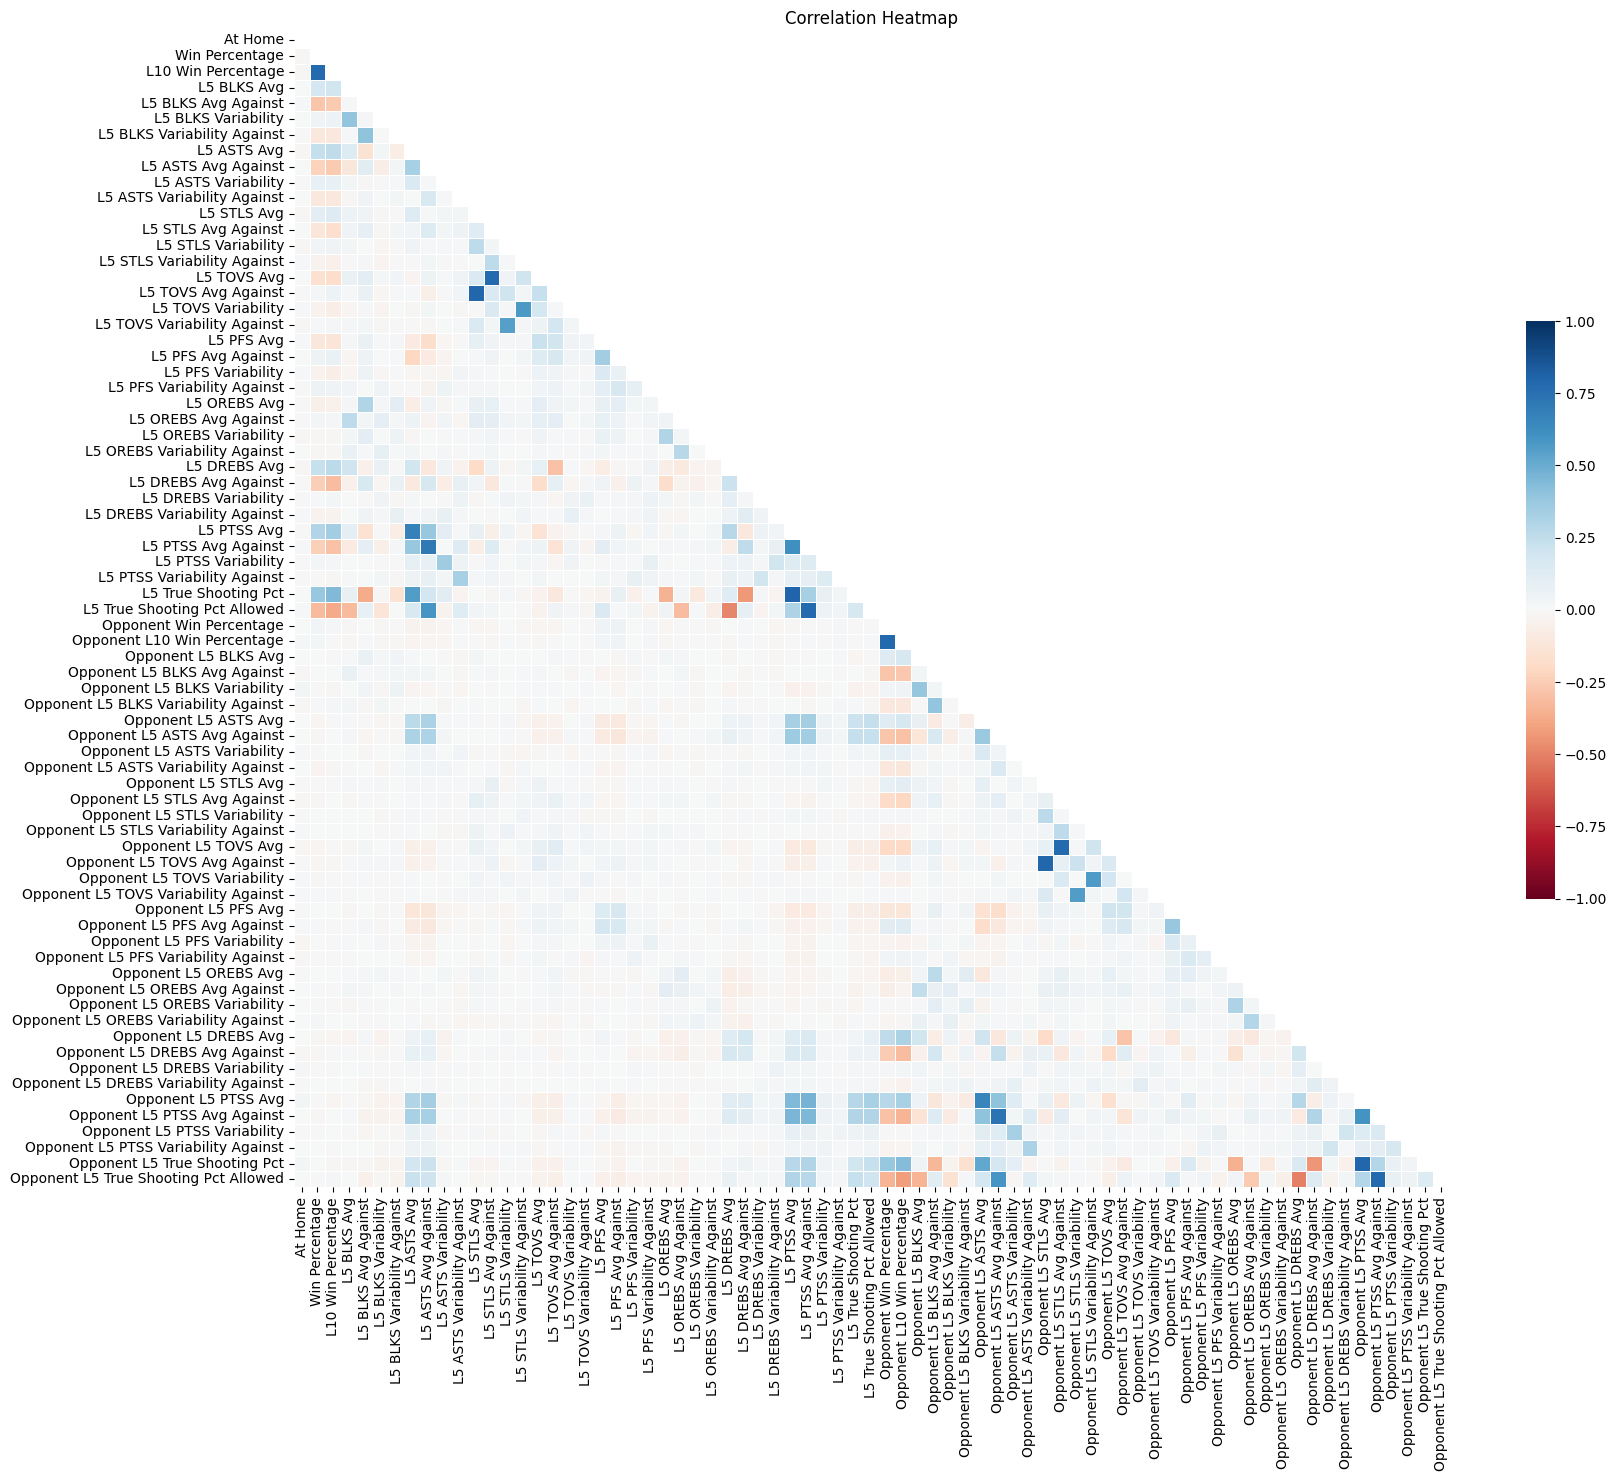

In [82]:
corr = X_train.corr()
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

f, ax = plt.subplots(figsize=(20, 15))
sns.heatmap(corr, mask=mask, cmap='RdBu', vmax=1, vmin=-1, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.title("Correlation Heatmap")
plt.show() 

Some observations from the table above include: 
* Strong correlation between efficiency (True Shooting Percentage) and scoring (Avg Points Scored Over Last N Games), which is expected
* Strong correlation between points scored and assists over last n games, which makes sense
* Strong correlation between Steals and Turnovers Forced

#### Pairplot Graph

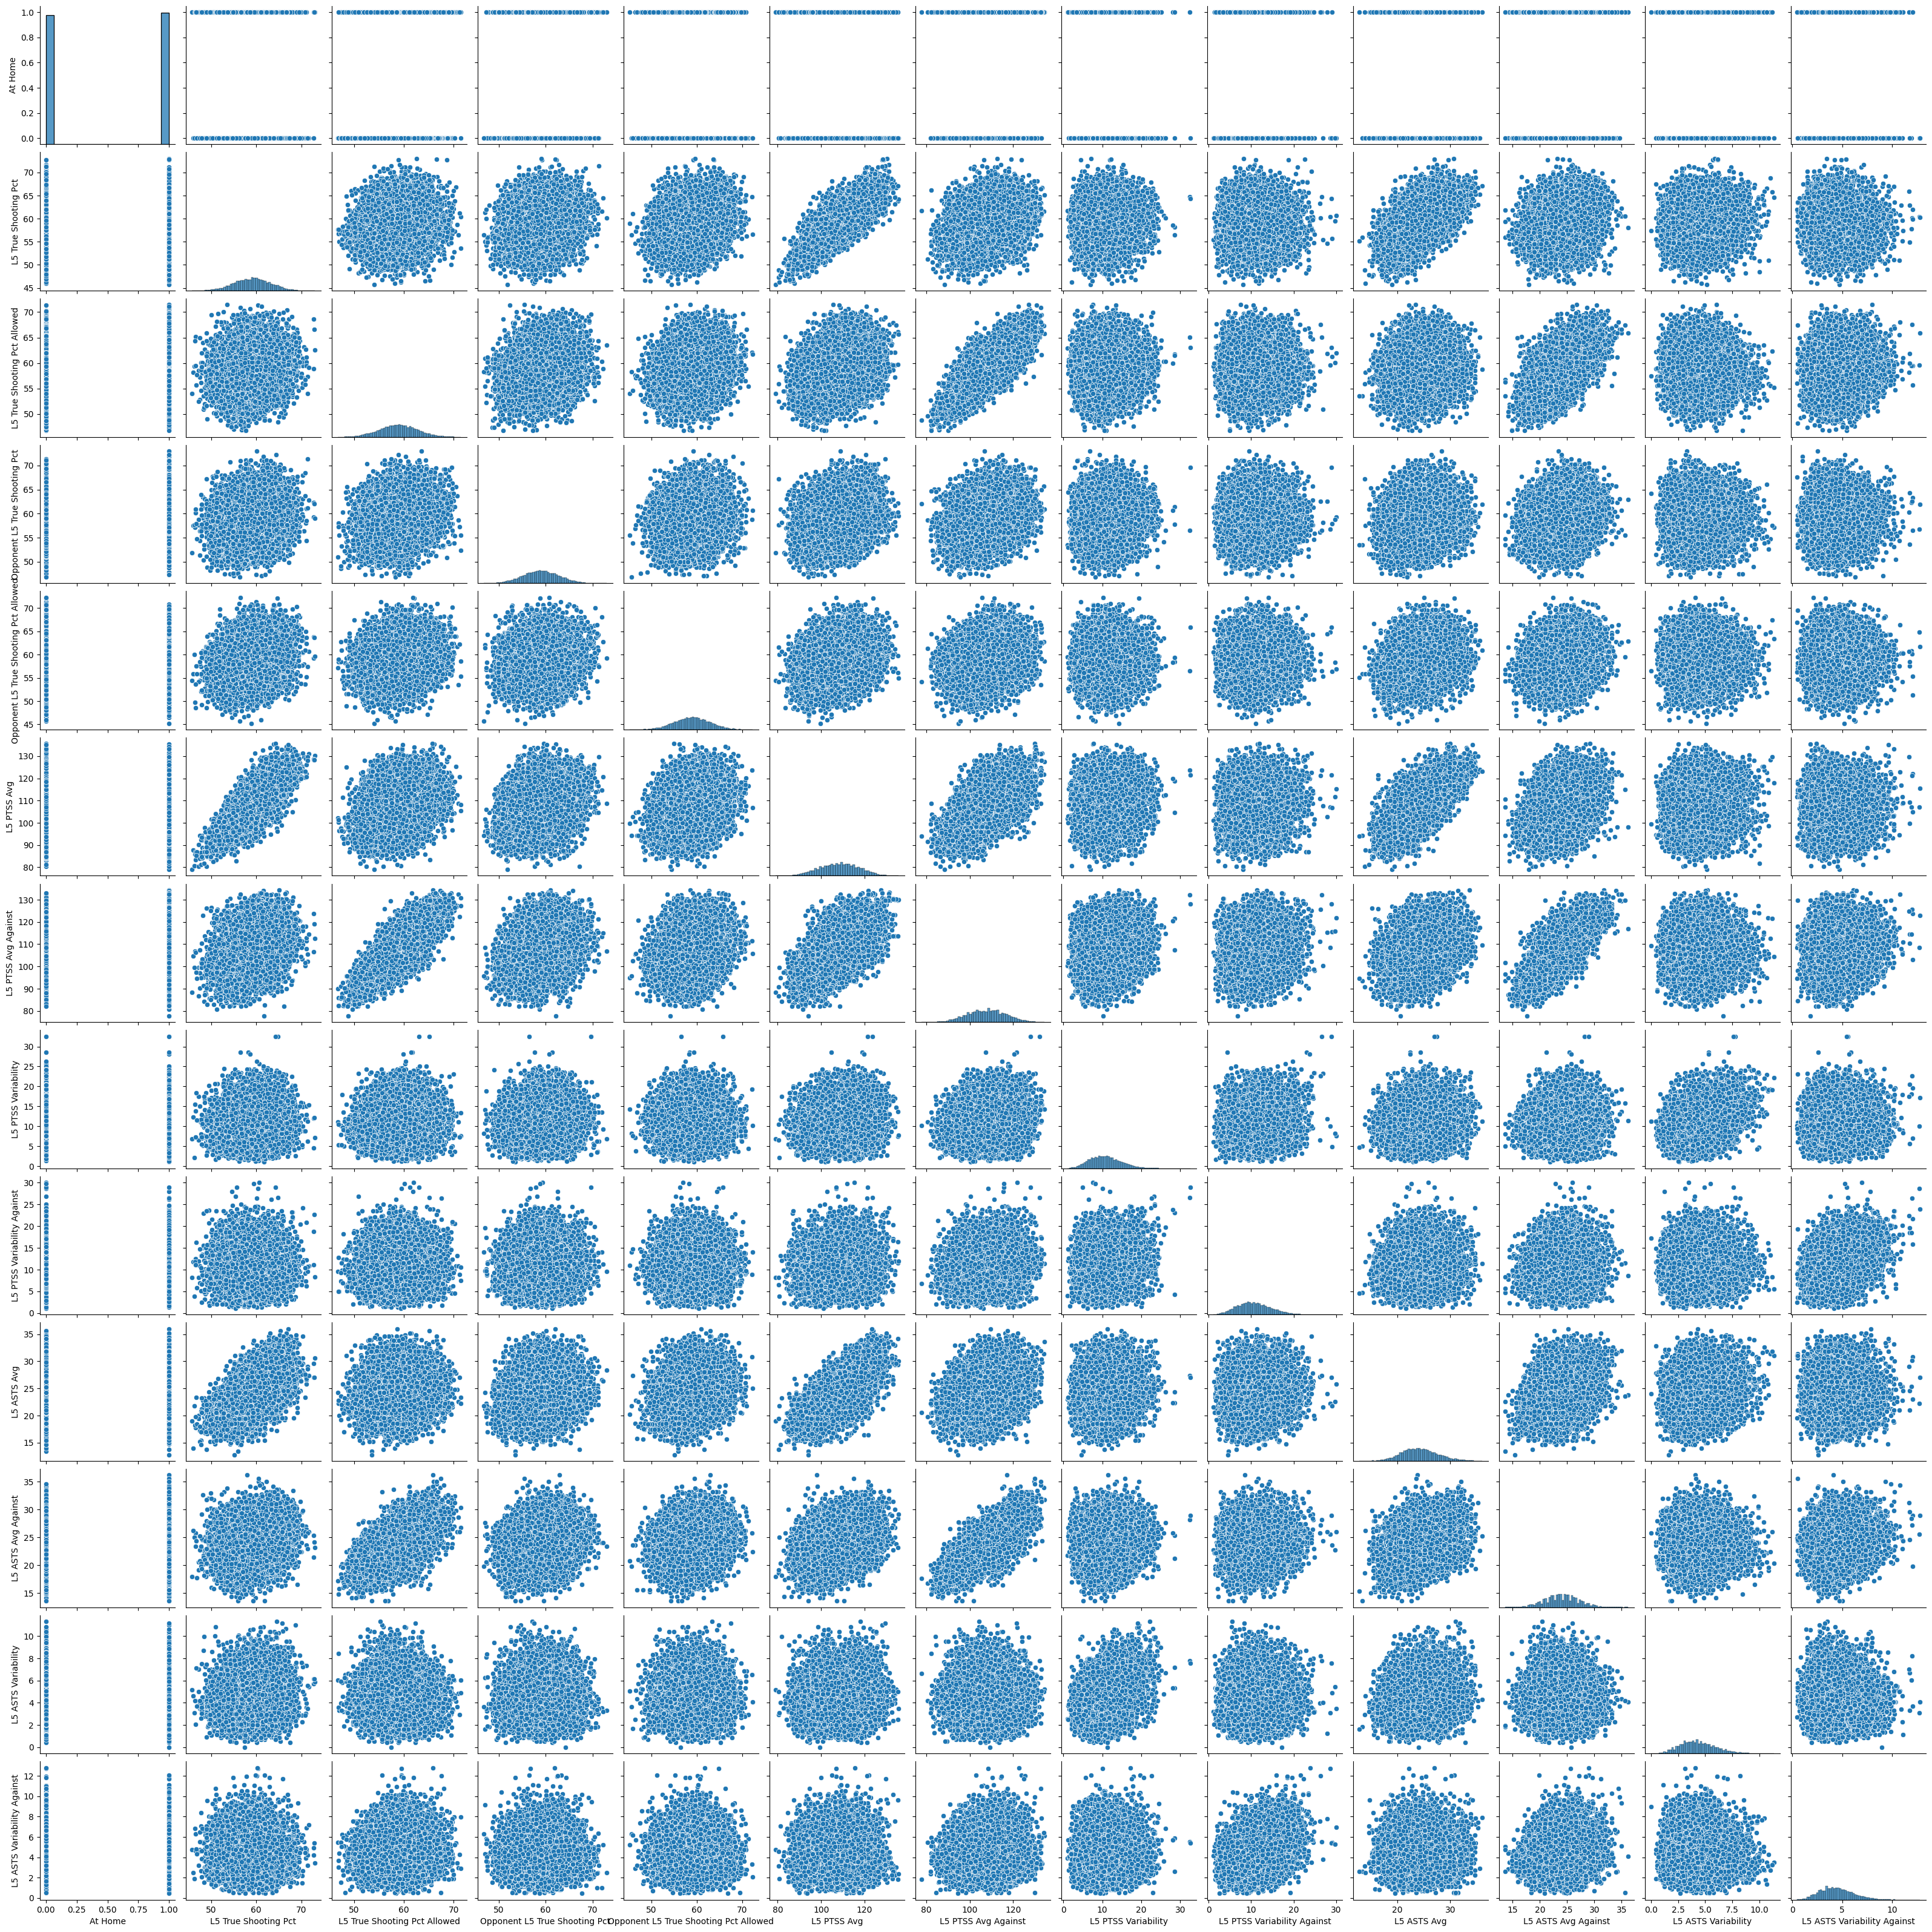

In [83]:
# To avoid crashing kernel, focus on subset of features inspired by
# observations seen above (Points, Assists, True Shooting Pct)
pairplot_features = ['At Home', f'L{window_size} True Shooting Pct', f'L{window_size} True Shooting Pct Allowed',
                     f'Opponent L{window_size} True Shooting Pct', f'Opponent L{window_size} True Shooting Pct Allowed',
                     f'L{window_size} PTSS Avg', f'L{window_size} PTSS Avg Against',
    f'L{window_size} PTSS Variability', f'L{window_size} PTSS Variability Against',
    f'L{window_size} ASTS Avg', f'L{window_size} ASTS Avg Against',
    f'L{window_size} ASTS Variability', f'L{window_size} ASTS Variability Against']
sns.pairplot(X_train[pairplot_features])

#### PCA

Principal Component Analysis is a statistical technique that takes a high-dimensional dataset (lots of features) and projects into a lower dimensional space in a way that preserves information (maximizes variance). We replace our features with principal components that encode information about the features (as each PC is a linear combination of the features), in particular which ones are the most important. Given that we have over 70 features, dimensionality reduction can assist us in understanding which features are the most important and help make our model less redundant.

Note that PCA is NOT scale invariant, so we must standardize our feature dataset (X) for this model. Here we will be using X_train

##### Standardize Data + Plot Cumulative Importance of PCs

Here we start by standardizing the data, and then conduct PCA
on this new dataset. We then use `explained_variance_ratio` to 
find the minimum number of components needed to reach a certain
threshold of explained variance (in this case 80%), and plot these
findings

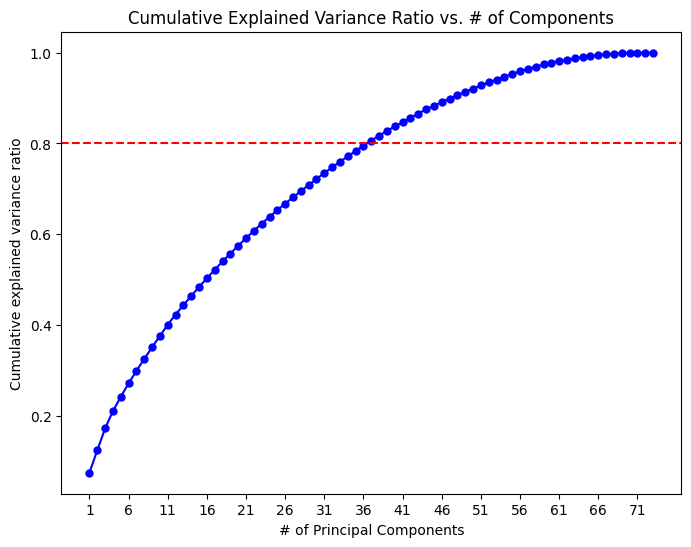

In [84]:
# Standardize data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Conduct PCA on standardized data
pca = PCA()
rand = pca.fit_transform(X_train_scaled)

# Get the relative importance of each eigenvector and cumulatively sum
explained_variance_ratios = pca.explained_variance_ratio_
cum_evr = np.cumsum(explained_variance_ratios)

# How many PCs we need to acquire 80% of the variance
n_components = np.argmax(cum_evr >= 0.8) + 1

# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(range(1, len(cum_evr) + 1), cum_evr, marker='o', markersize=5, color='blue')
ax.axhline(y=0.8, color='red', linestyle='--')
ax.set_xticks([x for x in range(1,len(X.columns),5)])
ax.set_xlabel('# of Principal Components')
ax.set_ylabel('Cumulative explained variance ratio')
ax.set_title('Cumulative Explained Variance Ratio vs. # of Components')
plt.show()

##### Determine Feature Importance

For each principal component calculated above, determine the n most important features, as determined by explained variance. Recall PC1 is the most important eigenvector. Helpful illustration of the procedure found [here](https://stackoverflow.com/questions/50796024/feature-variable-importance-after-a-pca-analysis)

Note that we will be referencing the variables here in Model 2: Logistic Regression with PCA

In [85]:
# Conduct PCA on with the minimum number of components needed to reach 80%
pca_final = PCA(n_components)
X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca = pca_final.transform(X_test_scaled)

# Determine how many important features per PC we want to observe, and note
# that the number must be negative 
top_n_features = -5

most_important_features = [np.argpartition(np.abs(pca_final.components_[i]), top_n_features)[top_n_features:]
                           for i in range(n_components)]
initial_feature_names = X_train.columns

# Using those indices, find the relevant features
most_important_names = [list(initial_feature_names[most_important_features[i]]) for i in range(n_components)]

# Create a list of identical length that will rank the features in order of most explained variance
pc_list = ["PC"+str(x) for x in range(1, n_components+1)]

# Combine the two previous columns under one dataframe
df = pd.DataFrame()
df['Principal Component'] = pc_list
df['5 Most Important Statistics (in order)'] = most_important_names
with pd.option_context('display.max_colwidth', None):
  display(df)

,Principal Component,5 Most Important Statistics (in order)
0,PC1,"[Opponent L5 ASTS Avg Against, L5 PTSS Avg, Opponent L5 PTSS Avg Against, L5 PTSS Avg Against, Opponent L5 PTSS Avg]"
1,PC2,"[L10 Win Percentage, Opponent L5 True Shooting Pct Allowed, Opponent L10 Win Percentage, Opponent L5 True Shooting Pct, Opponent Win Percentage]"
2,PC3,"[Opponent L10 Win Percentage, L5 True Shooting Pct, L10 Win Percentage, Win Percentage, L5 True Shooting Pct Allowed]"
3,PC4,"[Opponent L5 TOVS Avg Against, L5 TOVS Avg Against, L5 TOVS Avg, L5 STLS Avg Against, L5 STLS Avg]"
4,PC5,"[L5 TOVS Avg Against, L5 STLS Avg, Opponent L5 STLS Variability, Opponent L5 TOVS Avg Against, Opponent L5 STLS Avg]"
5,PC6,"[Opponent L5 TOVS Variability, L5 TOVS Avg, Opponent L5 STLS Variability Against, Opponent L5 TOVS Avg, Opponent L5 STLS Avg Against]"
6,PC7,"[L5 STLS Avg, Opponent L5 BLKS Avg, Opponent L5 DREBS Avg, L5 DREBS Avg, L5 TOVS Avg Against]"
7,PC8,"[Opponent L5 PFS Avg Against, L5 DREBS Avg, Opponent L5 BLKS Avg, Opponent L5 True Shooting Pct, Opponent L5 True Shooting Pct Allowed]"
8,PC9,"[L5 PFS Avg Against, L5 TOVS Variability Against, L5 STLS Avg, L5 STLS Variability, L5 True Shooting Pct]"
9,PC10,"[L5 PFS Avg Against, L5 STLS Variability Against, Opponent L5 PFS Avg Against, L5 PFS Avg, L5 TOVS Variability]"


### Model 1: Logistic Regression

We are working on a classification problem, and so it makes sense to use a Logistic Regression model for our baseline; here we start with a vanilla model and then in a subsequent section use GridSearch to optimally tune our hyperparameters.

We use accuracy score to gauge how effective our model is, but also explore precision and recall.

#### Vanilla Logistic Regression (Baseline)

In [86]:
log_reg1 = LogisticRegression(solver='saga',penalty=None,random_state=random_seed)
log_reg1.fit(X_train, y_train)
vanila_log_reg_preds = log_reg1.predict(X_test)
vanila_log_reg_acc = round(100 * log_reg1.score(X_test, y_test),2)

/Users/nakadi/Documents/GitHub/NBA_DataViz-and-ML_Projs/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Model's test accuracy is 63.58%
 the precision is 64.99% 
 the recall is 64.16% 
 the f-score is 64.57%


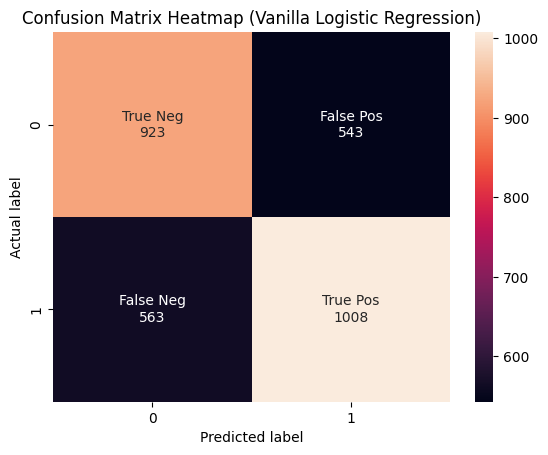

In [87]:
cm = confusion_matrix(y_test,vanila_log_reg_preds)
group_names = ["True Neg","False Pos","False Neg","True Pos"]
group_counts = ["{0:0.0f}".format(value) for value in
                cm.flatten()]
labels = [f"{v1}\n{v2}" for v1, v2 in
          zip(group_names,group_counts)]
labels = np.asarray(labels).reshape(2,2)

test_accuracy = (cm[0][0] + cm[1][1]) / (cm[0][0] + cm[1][1] + cm[0][1] + cm[1][0])
precision = cm[1][1] / (cm[1][1]+cm[0][1])
recall = cm[1][1] / (cm[1][1]+cm[1][0])

f_measure = (2 * precision * recall) / (precision + recall)

final_string = "Model's test accuracy is {}%\n the precision is {}% \n the recall is {}% \n the f-score is {}%"\
.format(round(100*test_accuracy,2), round(100*precision,2), round(100*recall,2), round(100*f_measure,2))
print(final_string)
sns.heatmap(cm, annot=labels,fmt='')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.title("Confusion Matrix Heatmap (Vanilla Logistic Regression)")
plt.show()


#### Tuned Logistic Regression

Experiment with Regularization Parameters

In [88]:
# Regularization with help of GridSearch
# "l1_ratio":[0.1 * x for x in range(11)]
best_score = 0
params = {'C':[1e-2, 1e-1, 1, 10, 100, 1000]}
log_reg = LogisticRegression(solver='saga',penalty='elasticnet',max_iter=1000,l1_ratio=1)

if DO_SEARCH:
    for param_set in ParameterGrid(params):
        log_reg.set_params(**param_set)
        log_reg.fit(X_train,y_train)
        # save best grid set
        score = log_reg.score(X_test,y_test )
        if score > best_score:
            best_score = score
            best_grid = param_set


# grid_search = RandomizedSearchCV(log_reg, param_distributions = params, n_iter = 30, cv = 5, scoring = 'accuracy', random_state = random_seed)


In [89]:
# Use best performing model

log_reg = LogisticRegression(C = 1, solver='saga',penalty='elasticnet',l1_ratio=1,max_iter=1000,
                             random_state=random_seed)
log_reg.fit(X_train, y_train)
tuned_log_reg_preds = log_reg.predict(X_test)
tuned_log_reg_acc = round(100*log_reg.score(X_test, y_test),2)

/Users/nakadi/Documents/GitHub/NBA_DataViz-and-ML_Projs/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Model's test accuracy is 65.06%
 the precision is 66.43% 
 the recall is 65.63% 
 the f-score is 66.03%


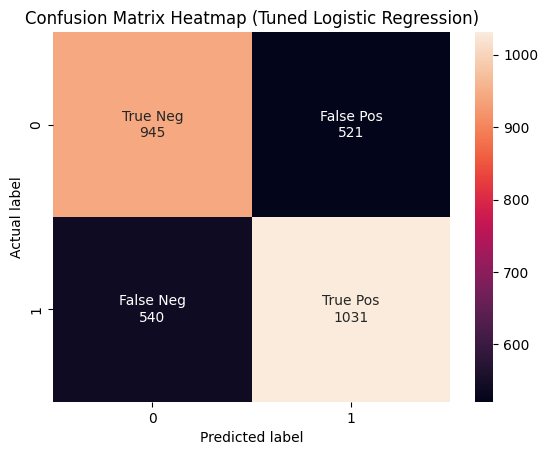

In [90]:
cm = confusion_matrix(y_test,tuned_log_reg_preds)
group_names = ["True Neg","False Pos","False Neg","True Pos"]
group_counts = ["{0:0.0f}".format(value) for value in
                cm.flatten()]
labels = [f"{v1}\n{v2}" for v1, v2 in
          zip(group_names,group_counts)]
labels = np.asarray(labels).reshape(2,2)

test_accuracy = (cm[0][0] + cm[1][1]) / (cm[0][0] + cm[1][1] + cm[0][1] + cm[1][0])
precision = cm[1][1] / (cm[1][1]+cm[0][1])
recall = cm[1][1] / (cm[1][1]+cm[1][0])

f_measure = (2 * precision * recall) / (precision + recall)

final_string = "Model's test accuracy is {}%\n the precision is {}% \n the recall is {}% \n the f-score is {}%"\
.format(round(100*test_accuracy,2), round(100*precision,2), round(100*recall,2), round(100*f_measure,2))
print(final_string)
sns.heatmap(cm, annot=labels,fmt='')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.title("Confusion Matrix Heatmap (Tuned Logistic Regression)")
plt.show()

### Model 2: Logistic Regression with PCA

Recall the work we did with PCA in the EDA section; here we will run our best-performing Logistic Regression model on our scaled datasets

In [91]:
# Use best-performing model up to this point
log_reg_pca = LogisticRegression(C = 1, solver='saga',penalty='elasticnet',l1_ratio=1,random_state=random_seed)
log_reg_pca.fit(X_train_pca, y_train)

# Make predictions on the test set
pca_log_reg_preds = log_reg_pca.predict(X_test_pca)

# Calculate accuracy of the model on the test set
pca_log_reg_acc = round(100*log_reg_pca.score(X_test_pca, y_test),2)

Model's test accuracy is 64.18%
 the precision is 65.65% 
 the recall is 64.48% 
 the f-score is 65.06%


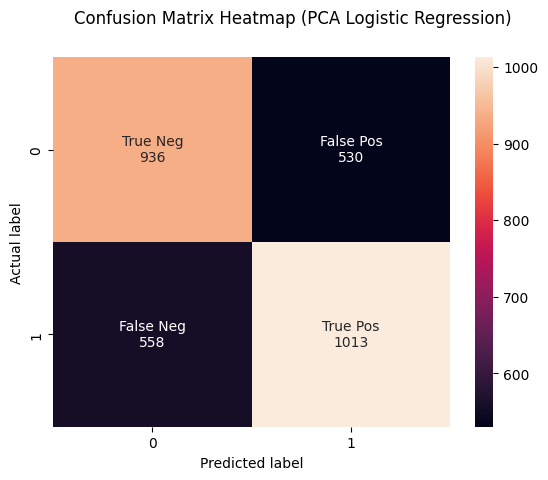

In [92]:
cm = confusion_matrix(y_test,pca_log_reg_preds)
group_names = ["True Neg","False Pos","False Neg","True Pos"]
group_counts = ["{0:0.0f}".format(value) for value in
                cm.flatten()]
labels = [f"{v1}\n{v2}" for v1, v2 in
          zip(group_names,group_counts)]
labels = np.asarray(labels).reshape(2,2)

test_accuracy = (cm[0][0] + cm[1][1]) / (cm[0][0] + cm[1][1] + cm[0][1] + cm[1][0])
precision = cm[1][1] / (cm[1][1]+cm[0][1])
recall = cm[1][1] / (cm[1][1]+cm[1][0])

f_measure = (2 * precision * recall) / (precision + recall)

final_string = "Model's test accuracy is {}%\n the precision is {}% \n the recall is {}% \n the f-score is {}%"\
.format(round(100*test_accuracy,2), round(100*precision,2), round(100*recall,2), round(100*f_measure,2))
print(final_string)
sns.heatmap(cm, annot=labels,fmt='')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.suptitle("Confusion Matrix Heatmap (PCA Logistic Regression)")
plt.show()

### Model 3: Random Forest

Now we start to look at decision tree classifiers. We start by exploring one of the most popular Boostrap Aggregation models, Random Forest Models

#### Vanilla Random Forest

In [93]:
# Vanilla RF model
rf = RandomForestClassifier(random_state = random_seed)
rf = rf.fit(X_train,y_train)
vanilla_rf_preds = rf.predict(X_test)
vanilla_rf_acc = round(100*rf.score(X_test,y_test),2)

Model's test accuracy is 64.21%
 the precision is 65.47% 
 the recall is 65.18% 
 the f-score is 65.33%


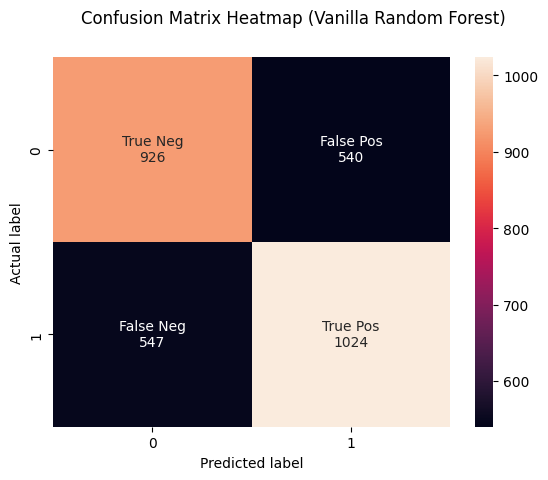

In [94]:
cm = confusion_matrix(y_test,vanilla_rf_preds)
group_names = ["True Neg","False Pos","False Neg","True Pos"]
group_counts = ["{0:0.0f}".format(value) for value in
                cm.flatten()]
labels = [f"{v1}\n{v2}" for v1, v2 in
          zip(group_names,group_counts)]
labels = np.asarray(labels).reshape(2,2)

test_accuracy = (cm[0][0] + cm[1][1]) / (cm[0][0] + cm[1][1] + cm[0][1] + cm[1][0])
precision = cm[1][1] / (cm[1][1]+cm[0][1])
recall = cm[1][1] / (cm[1][1]+cm[1][0])

f_measure = (2 * precision * recall) / (precision + recall)

final_string = "Model's test accuracy is {}%\n the precision is {}% \n the recall is {}% \n the f-score is {}%"\
.format(round(100*test_accuracy,2), round(100*precision,2), round(100*recall,2), round(100*f_measure,2))
print(final_string)
sns.heatmap(cm, annot=labels,fmt='')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.suptitle("Confusion Matrix Heatmap (Vanilla Random Forest)")
plt.show()

##### Feature Importance (Vanilla RF)

In a similar vein to PCA, we can use our random forest model to determine the most important features. Here, most important is defined as the features which, when used as the splitting criterion for a decision tree, have the largest decrease in node impurity (given this is a classification problem)

In [95]:
feature_imp_df = pd.DataFrame({'Feature': X_train.columns, 'Gini Importance': rf.feature_importances_}).sort_values('Gini Importance', ascending=False) 
feature_imp_df.head(10)

# Note: more equal spread of feature importance across features
# compared to the tuned model

,Feature,Gini Importance
37,Opponent Win Percentage,0.042560
1,Win Percentage,0.042458
35,L5 True Shooting Pct,0.017549
71,Opponent L5 True Shooting Pct,0.017327
38,Opponent L10 Win Percentage,0.016759
2,L10 Win Percentage,0.014638
72,Opponent L5 True Shooting Pct Allowed,0.014579
69,Opponent L5 PTSS Variability,0.014460
67,Opponent L5 PTSS Avg,0.014451
70,Opponent L5 PTSS Variability Against,0.014429


#### Tuned Random Forest

##### (LONG RUNTIME) Run GridSearch

In [96]:
if DO_SEARCH:
    rf_tuned = RandomForestClassifier(random_state = random_seed)
    rf_params = {'max_depth':np.arange(3,20),'n_estimators':np.arange(100,1100,100)}
    search = GridSearchCV(rf_tuned, param_grid = rf_params, random_state = random_seed)
    search.fit(X_train,y_train)
    print(search.best_params_)
    print(search.score(X_test, y_test))

##### Get Accuracy of Tuned RF Model

In [97]:
# Best Performing model found so far: depth = 6, estimators = 300
rf_tuned = RandomForestClassifier(random_state = random_seed,max_depth=6,n_estimators=300)

rf_tuned.fit(X_train,y_train)
tuned_rf_preds = rf_tuned.predict(X_test)
tuned_rf_acc = round(100*rf_tuned.score(X_test,y_test),2)

Model's test accuracy is 65.1%
 the precision is 65.59% 
 the recall is 68.43% 
 the f-score is 66.98%


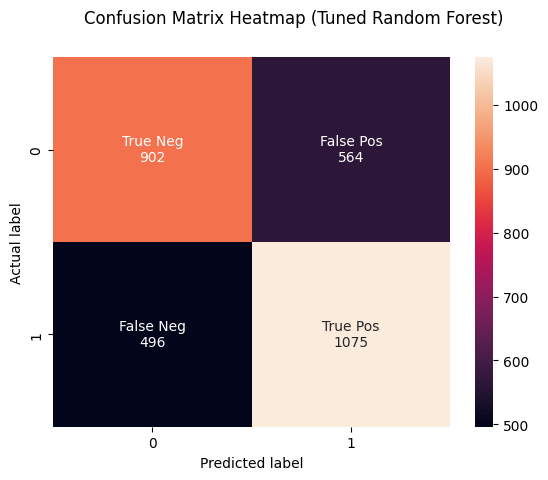

In [98]:
cm = confusion_matrix(y_test,tuned_rf_preds)
group_names = ["True Neg","False Pos","False Neg","True Pos"]
group_counts = ["{0:0.0f}".format(value) for value in
                cm.flatten()]
labels = [f"{v1}\n{v2}" for v1, v2 in
          zip(group_names,group_counts)]
labels = np.asarray(labels).reshape(2,2)

test_accuracy = (cm[0][0] + cm[1][1]) / (cm[0][0] + cm[1][1] + cm[0][1] + cm[1][0])
precision = cm[1][1] / (cm[1][1]+cm[0][1])
recall = cm[1][1] / (cm[1][1]+cm[1][0])

f_measure = (2 * precision * recall) / (precision + recall)

final_string = "Model's test accuracy is {}%\n the precision is {}% \n the recall is {}% \n the f-score is {}%"\
.format(round(100*test_accuracy,2), round(100*precision,2), round(100*recall,2), round(100*f_measure,2))
print(final_string)
sns.heatmap(cm, annot=labels,fmt='')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.suptitle("Confusion Matrix Heatmap (Tuned Random Forest)")
plt.show()

##### Feature Importance (Tuned RF)


In [99]:
importances = rf_tuned.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': X_train.columns, 'Gini Importance': importances}).sort_values('Gini Importance', ascending=False) 
print(feature_imp_df.head(10))

                          Feature  Gini Importance
37        Opponent Win Percentage         0.154285
1                  Win Percentage         0.148173
38    Opponent L10 Win Percentage         0.073336
2              L10 Win Percentage         0.067779
0                         At Home         0.056927
35           L5 True Shooting Pct         0.032940
71  Opponent L5 True Shooting Pct         0.027373
31                    L5 PTSS Avg         0.022881
67           Opponent L5 PTSS Avg         0.017334
4             L5 BLKS Avg Against         0.015898


### Model 4: Boosting (XGBoost)

Another decision tree classifier. We opt to use the most powerful and popular boosting model known to us, XGBoost.

#### Vanilla XGBoost

In [100]:
xgb_model = xgb.XGBClassifier(objective='binary:logistic', random_state=random_seed)
xgb_model.fit(X_train,y_train)
vanilla_xgb_preds = xgb_model.predict(X_test)
vanilla_xgb_acc = round(100*xgb_model.score(X_test,y_test),2)

Model's test accuracy is 63.15%
 the precision is 64.0% 
 the recall is 65.75% 
 the f-score is 64.87%


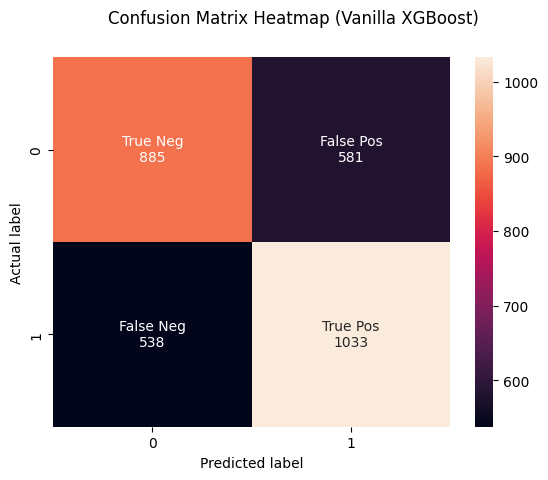

In [101]:
cm = confusion_matrix(y_test,vanilla_xgb_preds)
group_names = ["True Neg","False Pos","False Neg","True Pos"]
group_counts = ["{0:0.0f}".format(value) for value in
                cm.flatten()]
labels = [f"{v1}\n{v2}" for v1, v2 in
          zip(group_names,group_counts)]
labels = np.asarray(labels).reshape(2,2)

test_accuracy = (cm[0][0] + cm[1][1]) / (cm[0][0] + cm[1][1] + cm[0][1] + cm[1][0])
precision = cm[1][1] / (cm[1][1]+cm[0][1])
recall = cm[1][1] / (cm[1][1]+cm[1][0])

f_measure = (2 * precision * recall) / (precision + recall)

final_string = "Model's test accuracy is {}%\n the precision is {}% \n the recall is {}% \n the f-score is {}%"\
.format(round(100*test_accuracy,2), round(100*precision,2), round(100*recall,2), round(100*f_measure,2))
print(final_string)
sns.heatmap(cm, annot=labels,fmt='')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.suptitle("Confusion Matrix Heatmap (Vanilla XGBoost)")
plt.show()

##### Tuned XGBoost

In [102]:
# # Build XGBoost Model

# Best hyperparameters:  {'subsample': 0.5, 'max_depth': 9, 'gamma': 10, 'eta': 0.001, 'colsample_bytree': 1}
# Best score: 65.26%

param_grid = {
    'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
    'eta': [0.1, 0.01, 0.001],
    'n_estimators': [25, 50, 75, 100],
    'gamma': [0, 0.1, 0.01],
    'subsample': [0.5, 0.8, 1],
    'colsample_bytree': [0.5, 0.8, 1]
}

# Initialize Model + Define the search method
if DO_SEARCH:
    xgb_model = xgb.XGBClassifier(objective='binary:logistic', random_state=random_seed)
    xgb_search = RandomizedSearchCV(param_distributions = param_grid, n_iter = 50, cv = 5, scoring = 'accuracy', random_state = random_seed)
    # Fit the search to the data
    xgb_search.fit(X_train, y_train)

In [103]:
# Best Model so far:
subsample = 0.5
n_estimators = 300
max_depth = 3
reg_param = 0.05
eta = 0.01
xgb_model_tuned = xgb.XGBClassifier(objective='binary:logistic', random_state=random_seed,
                                max_depth = max_depth, n_estimators = n_estimators, subsample = subsample,
                                eta = eta, alpha = reg_param, reg_lambda = 1 - reg_param)
xgb_model_tuned.fit(X_train, y_train)
tuned_xgb_preds = xgb_model_tuned.predict(X_test)
tuned_xgb_acc = round(xgb_model_tuned.score(X_test,y_test) * 100,2)

Model's test accuracy is 66.05%
 the precision is 66.81% 
 the recall is 68.3% 
 the f-score is 67.55%


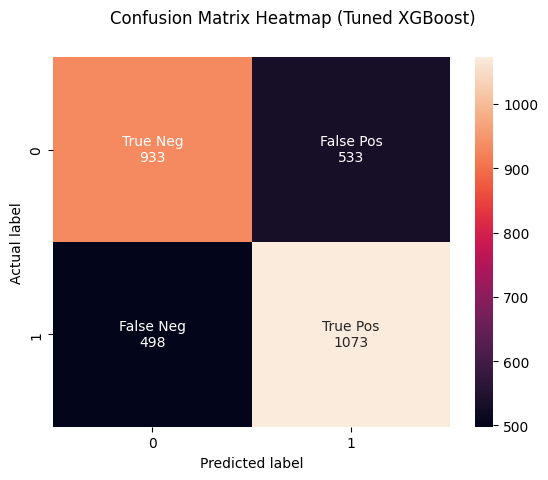

In [104]:
cm = confusion_matrix(y_test,tuned_xgb_preds)
group_names = ["True Neg","False Pos","False Neg","True Pos"]
group_counts = ["{0:0.0f}".format(value) for value in
                cm.flatten()]
labels = [f"{v1}\n{v2}" for v1, v2 in
          zip(group_names,group_counts)]
labels = np.asarray(labels).reshape(2,2)

test_accuracy = (cm[0][0] + cm[1][1]) / (cm[0][0] + cm[1][1] + cm[0][1] + cm[1][0])
precision = cm[1][1] / (cm[1][1]+cm[0][1])
recall = cm[1][1] / (cm[1][1]+cm[1][0])

f_measure = (2 * precision * recall) / (precision + recall)

final_string = "Model's test accuracy is {}%\n the precision is {}% \n the recall is {}% \n the f-score is {}%"\
.format(round(100*test_accuracy,2), round(100*precision,2), round(100*recall,2), round(100*f_measure,2))
print(final_string)
sns.heatmap(cm, annot=labels,fmt='')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.suptitle("Confusion Matrix Heatmap (Tuned XGBoost)")
plt.show()

### Model 5: Support Vector Classifier

For our last model (for the time being) I explored a Support Vector Classifier, a Supervised Learning Method that is effective in high dimensional spaces, provides kernels to identify the optimal decision function and given that our output is binary, we should expect fairly good accuracy results

#### Linear Kernel (Vanilla)

In [105]:
svc = SVC(C=1, kernel='linear', random_state=random_seed)
svc.fit(X_train, y_train)
vanilla_svc_preds = svc.predict(X_test)
vanilla_svc_lin_acc = round(100*svc.score(X_test,y_test),2)

Model's test accuracy is 66.15%
 the precision is 67.53% 
 the recall is 66.58% 
 the f-score is 67.05%


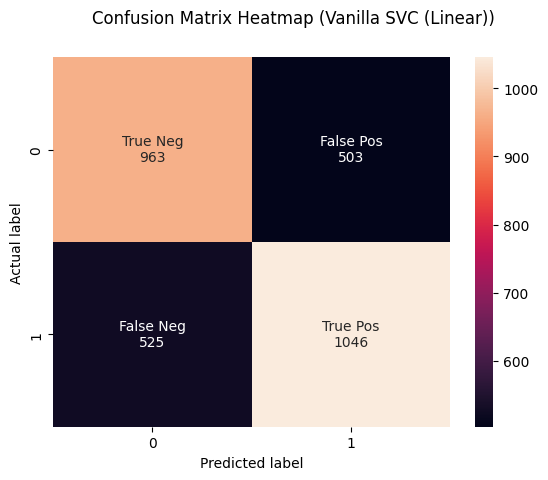

In [106]:
cm = confusion_matrix(y_test,vanilla_svc_preds)
group_names = ["True Neg","False Pos","False Neg","True Pos"]
group_counts = ["{0:0.0f}".format(value) for value in
                cm.flatten()]
labels = [f"{v1}\n{v2}" for v1, v2 in
          zip(group_names,group_counts)]
labels = np.asarray(labels).reshape(2,2)

test_accuracy = (cm[0][0] + cm[1][1]) / (cm[0][0] + cm[1][1] + cm[0][1] + cm[1][0])
precision = cm[1][1] / (cm[1][1]+cm[0][1])
recall = cm[1][1] / (cm[1][1]+cm[1][0])

f_measure = (2 * precision * recall) / (precision + recall)

final_string = "Model's test accuracy is {}%\n the precision is {}% \n the recall is {}% \n the f-score is {}%"\
.format(round(100*test_accuracy,2), round(100*precision,2), round(100*recall,2), round(100*f_measure,2))
print(final_string)
sns.heatmap(cm, annot=labels,fmt='')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.suptitle("Confusion Matrix Heatmap (Vanilla SVC (Linear))")
plt.show()

#### Linear Kernel (Tuned)

In [107]:
c_values = [0.001, 0.01, 0.1, 1, 2.5,5,10,20]
tuned_svc_preds = None
tuned_svc_acc = 0

if DO_SEARCH:
    for coef in c_values:
        print(coef)
        svc = SVC(C=coef, kernel='linear', random_state=random_seed)
        svc.fit(X_train, y_train)
        if svc.score(X_test,y_test) > tuned_svc_acc:
            tuned_svc_preds = svc.predict(X_test)
            tuned_svc_acc = round(100*svc.score(X_test,y_test),2)

In [108]:
svc_tuned = SVC(C=1, kernel='linear', random_state=random_seed)
svc_tuned.fit(X_train, y_train)
tuned_svc_preds = svc_tuned.predict(X_test)
tuned_svc_acc = round(100*svc_tuned.score(X_test,y_test),2)

Note: For now C = 1 appears to be best parameter
Model's test accuracy is 66.15%
 the precision is 67.53% 
 the recall is 66.58% 
 the f-score is 67.05%


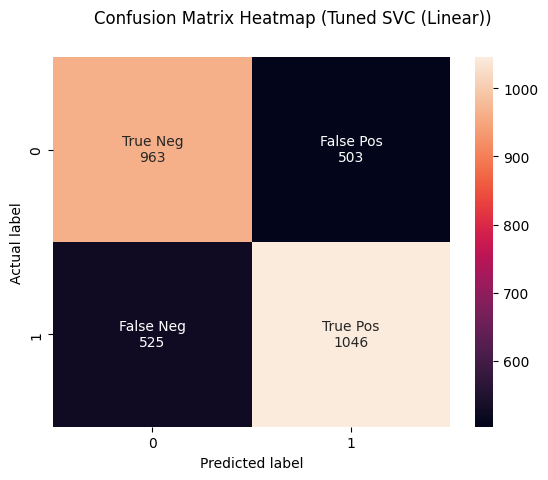

In [109]:
cm = confusion_matrix(y_test,tuned_svc_preds)
group_names = ["True Neg","False Pos","False Neg","True Pos"]
group_counts = ["{0:0.0f}".format(value) for value in
                cm.flatten()]
labels = [f"{v1}\n{v2}" for v1, v2 in
          zip(group_names,group_counts)]
labels = np.asarray(labels).reshape(2,2)

test_accuracy = (cm[0][0] + cm[1][1]) / (cm[0][0] + cm[1][1] + cm[0][1] + cm[1][0])
precision = cm[1][1] / (cm[1][1]+cm[0][1])
recall = cm[1][1] / (cm[1][1]+cm[1][0])

f_measure = (2 * precision * recall) / (precision + recall)
print("Note: For now C = 1 appears to be best parameter")
final_string = "Model's test accuracy is {}%\n the precision is {}% \n the recall is {}% \n the f-score is {}%"\
.format(round(100*test_accuracy,2), round(100*precision,2), round(100*recall,2), round(100*f_measure,2))
print(final_string)
sns.heatmap(cm, annot=labels,fmt='')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.suptitle("Confusion Matrix Heatmap (Tuned SVC (Linear))")
plt.show()

#### Radial Kernal

In [110]:
svc = SVC(C=1, kernel='rbf', random_state=random_seed)
svc.fit(X_train, y_train)
vanilla_svc_rbf_acc = round(100*svc.score(X_test,y_test),2)

#### Poly Kernel

In [111]:
svc = SVC(C=1, kernel='poly', random_state=random_seed)
svc.fit(X_train, y_train)
round(100*svc.score(X_test,y_test),2)

61.67

Note: Radial & Poly Kernel SVCs do not perform as well as linear kernel. And for the time being, the vanilla SVC with a linear kernel has the best parameters, but this will be checked with further tuning. It should be noted that the default kernel of SVC is rbf, which was fairly low at 63.09 percent

### Model Results

In [112]:
accuracies = [vanila_log_reg_acc, tuned_log_reg_acc, pca_log_reg_acc,
              vanilla_rf_acc, tuned_rf_acc, vanilla_xgb_acc, tuned_xgb_acc,
              vanilla_svc_lin_acc, vanilla_svc_rbf_acc]
accuracy_names = ["Logistic Regression Accuracy (Vanilla)", "Logistic Regression Accuracy (Tuned)",
                  "Logistic Regression Accuracy (PCA)", "Random Forest Accuracy (Vanilla)", "Random Forest Accuracy (Tuned)",
                  "XGBoost Accuracy (Vanilla)", "XGBoost Accuracy (Tuned)", "Linear SVC Accuracy (Best Performing)", 'Radial SVC Accuracy (Vanilla)']
table_df = pd.DataFrame([accuracy_names,accuracies])
table_df.index = ['Model','Accuracy']
table_df = table_df.transpose().sort_values(by='Accuracy',ascending=False)
(

    GT(table_df)
    .tab_header(title="NBA Model Classification Model Accuracies",
                subtitle = f'Aggregated Features taken from Last {window_size} Games')
    .tab_stub(rowname_col="Model")
    .fmt_number(columns=['Accuracy'], compact=True)
    .tab_source_note(
        source_note=("Note: Tuned models are still undergoing hyperparameter tuning")
    )
    .tab_stubhead(label="Model")
)


GT(_tbl_data=                                    Model Accuracy
7   Linear SVC Accuracy (Best Performing)    66.15
6                XGBoost Accuracy (Tuned)    66.05
4          Random Forest Accuracy (Tuned)     65.1
1    Logistic Regression Accuracy (Tuned)    65.06
3        Random Forest Accuracy (Vanilla)    64.21
2      Logistic Regression Accuracy (PCA)    64.18
0  Logistic Regression Accuracy (Vanilla)    63.58
5              XGBoost Accuracy (Vanilla)    63.15
8           Radial SVC Accuracy (Vanilla)    60.62, _body=<great_tables._gt_data.Body object at 0x12b701940>, _boxhead=Boxhead([ColInfo(var='Model', type=<ColInfoTypeEnum.stub: 2>, column_label='Model', column_align='left', column_width=None), ColInfo(var='Accuracy', type=<ColInfoTypeEnum.default: 1>, column_label='Accuracy', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x12b24c510>, _spanners=Spanners([]), _heading=Heading(title='NBA Model Classification Model Accuracies', subtitle='Aggregated Features taken from Last 5 Games', preheader=None), _stubhead='Model', _summary_rows=<great_tables._gt_data.SummaryRows object at 0x13236a0d0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x114bf5f30>, _source_notes=['Note: Tuned models are still undergoing hyperparameter tuning'], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x13236a210>, _formats=[<great_tables._gt_data.FormatInfo object at 0x132369e50>], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table', typ

## Log Models in MlFlow

#### Store Models

In [113]:
models = [
    (
        "Logistic Regression Baseline", 
        log_reg1, 
        (X_train, y_train),
        (X_test, y_test)
    ),
    (
        "Logistic Regression With PCA", 
        log_reg_pca, 
        (X_train_pca, y_train),
        (X_test_pca, y_test)
    ),
    (
        "Random Forest Classifier Baseline",
        rf, 
        (X_train, y_train),
        (X_test, y_test)
    ),
    (
        "Random Forest Classifier Tuned",
        rf_tuned, 
        (X_train, y_train),
        (X_test, y_test)
    ),
    (
        "XGBoost Classifier Baseline",
        xgb_model, 
        (X_train, y_train),
        (X_test, y_test)
    ),
    (
        "XGBoost Classifier Tuned",
        xgb_model_tuned, 
        (X_train, y_train),
        (X_test, y_test)
    ),
    (
        "SVC Classifier Linear Kernel Tuned",
        svc_tuned, 
        (X_train, y_train),
        (X_test, y_test)
    )
]

In [114]:
reports = []

for model_name, model, train_set, test_set in models:
    print(model_name)
    
    X_train = train_set[0]
    y_train = train_set[1]
    X_test = test_set[0]
    y_test = test_set[1]
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)
    reports.append(report)

Logistic Regression Baseline


/Users/nakadi/Documents/GitHub/NBA_DataViz-and-ML_Projs/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Logistic Regression With PCA
Random Forest Classifier Baseline
Random Forest Classifier Tuned
XGBoost Classifier Baseline
XGBoost Classifier Tuned
SVC Classifier Linear Kernel Tuned


#### Initialize MlFlow

In [120]:
# Initialize MLflow
mlflow.set_experiment("NBA Winners Models - test2")
mlflow.set_tracking_uri("http://127.0.0.1:5000")

2026/01/11 16:40:51 INFO mlflow.tracking.fluent: Experiment with name 'NBA Winners Models - test2' does not exist. Creating a new experiment.


Store All Models in MLFlow

In [121]:
for i, element in enumerate(models):
    model_name = element[0]
    model = element[1]
    report = reports[i]
    
    with mlflow.start_run(run_name=model_name):    
        print(model_name)    
        mlflow.log_param("model", model_name)
        mlflow.log_metric('accuracy', report['accuracy'])
        mlflow.log_metric('recall_class_1', report['1']['recall'])
        mlflow.log_metric('recall_class_0', report['0']['recall'])
        mlflow.log_metric('f1_score_macro', report['macro avg']['f1-score'])        
        
        if "XGB" in model_name:
            mlflow.xgboost.log_model(model,name=model_name)
        else:
            mlflow.sklearn.log_model(model,name=model_name)  

Logistic Regression Baseline
🏃 View run Logistic Regression Baseline at: http://127.0.0.1:5000/#/experiments/2/runs/2a2e2a22fa9e4bfe8554c0d8962bcef9
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2
Logistic Regression With PCA
🏃 View run Logistic Regression With PCA at: http://127.0.0.1:5000/#/experiments/2/runs/0cede0a385784c07a6a694c3588353c4
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2
Random Forest Classifier Baseline
🏃 View run Random Forest Classifier Baseline at: http://127.0.0.1:5000/#/experiments/2/runs/23d43507a53f48619a04670bee3701a8
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2
Random Forest Classifier Tuned
🏃 View run Random Forest Classifier Tuned at: http://127.0.0.1:5000/#/experiments/2/runs/a4a1e804146a4351a2ffb01bb014c45f
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2
XGBoost Classifier Baseline
🏃 View run XGBoost Classifier Baseline at: http://127.0.0.1:5000/#/experiments/2/runs/e3ae878b9135462c8867fa519dace620
🧪 V

Register Select Models

In [117]:
model_name = input("Enter the model name to register: ")
run_id = input("Enter the run ID to register the model: ")
model_uri = f"runs:/{run_id}/{model_name}"
mlflow.register_model(
    model_uri,model_name
    )

Successfully registered model 'XGBoost Classifier Tuned'.
2026/01/11 16:40:09 WARNING mlflow.tracking._model_registry.fluent: Run with id 0842de98871e4749ab9bbe3e19435fae has no artifacts at artifact path 'XGBoost Classifier Tuned', registering model based on models:/m-cd17f9b17fce4c65b55c7c2593907614 instead
2026/01/11 16:40:09 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: XGBoost Classifier Tuned, version 1
Created version '1' of model 'XGBoost Classifier Tuned'.


<ModelVersion: aliases=[], creation_timestamp=1768167609071, current_stage='None', deployment_job_state=<ModelVersionDeploymentJobState: current_task_name='', job_id='', job_state='DEPLOYMENT_JOB_CONNECTION_STATE_UNSPECIFIED', run_id='', run_state='DEPLOYMENT_JOB_RUN_STATE_UNSPECIFIED'>, description='', last_updated_timestamp=1768167609071, metrics=None, model_id=None, name='XGBoost Classifier Tuned', params=None, run_id='0842de98871e4749ab9bbe3e19435fae', run_link='', source='models:/m-cd17f9b17fce4c65b55c7c2593907614', status='READY', status_message=None, tags={}, user_id='', version='1'>

Load registered model

In [118]:
model_version = 1
model_name = input("Enter the model name to load: ")
model_uri = f"models:/{model_name}/{model_version}"
loaded_model = mlflow.xgboost.load_model(model_uri)
y_pred = loaded_model.predict(X_test)
y_pred[:4]

array([1, 1, 1, 1])

### General Observations

In the end, using a dataset that aggregated statistics over a team's previous 15 games, our tuned XGBoost Model had the best performance, at 67.2% test accuracy, with the interesting caveat that it had a rather poor testing accuracy without any tuning. The models followed a stable trend of improving with hyperparameter tuning (adding regularization as needed, toying with the maximum depth and number of trees for Decision Tree Models, etc.) with the exception of the SVC classifier.

In terms of things to focus on, every single model had a better recall when it came to predicting winners (1) than for predicting the loser of a game (0). The data imbalance between 1s and 0s was not too large to explain why this was consistently the case. Therefore, we know by definition that recall is the proportion of true positives in the set of samples that are actually positive (meaning true positives and false negatives), whereas precision is the proportion of correctly identified positives from the set of samples that were identified as positive by our model. Here, positive corresponds to 1 (Team 1 winning the game), so a true positive is where we predict Team 1 wins the game and that turns out to be the case.  There is typically a tradeoff between precision and recall, and right now our model does a better job at identifying wins than at avoiding cases of incorrectly predicting a win. I will look into ways to alter my models in order to see if prioritizing precision leads to better results.

In short, I have developed a unique approach to building a model that can predict the winner of an NBA game which has real-world utility and an easy enough way to start predicting the outcomes of games for the upcoming 2024-25 season. Of course my work is nowhere close to done as I continue to find approaches and emethods to improve the accuracy of my models. 

### Next Steps

* Continue exploring current research/literature to improve model selection, feature selection and engineering, etc. In particular, incorporate player data/roster data for the particular game, information relating to trades and injuries, etc. 
* Incorporate a similar model for the postseason/playoff simulator
* Start building neural nets/deep learning networks, along with other models like Gaussian Naive Bayes
* Continue tinkering with hyperparameter tuning (slight issue here as GridSearch and RandomSearch tend to be rather time-consuming)
* Begin converting this code into a class that users can easily run on their own end by calling methods, instead of just having to run the cells in this notebook

### Helpful Resources

* ACM Paper that provides in-depth analysis of most powerful models, best features (4 Factors), and so on (2023) [here](https://dl.acm.org/doi/fullHtml/10.1145/3635638.3635646)
* Medium article with accuracy around 70% (uses neural network) [here](https://medium.com/data-sports/netty-my-personal-nba-game-winner-predictor-63cc728025c5)
* Honors Thesis building upon previous models (contains literature review and determines best stats to explore) [here](https://digitalcommons.bryant.edu/cgi/viewcontent.cgi?article=1000&context=honors_data_science)
* Summary that outlines concerns like data imbalance, and not accounting for trades and injuries [here](https://www2.kenyon.edu/Depts/Math/hartlaub/Stat306%20Spring%202024/Executive%20Summary%20-%20Faiz%20andd%20Rafey.pdf)